# CALL CENTER DATASET ANALYSIS
### AUTOR: JUAN PABLO LUNA ZULETA
### GITHUB: github.com/JhonlunKnox

In [14]:
###------------------ IMPORTAR LIBRERÍAS ────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [15]:
# ── ESTILO GENERAL ──────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({
    'figure.facecolor': '#0f0f17',
    'axes.facecolor':   '#1a1a28',
    'axes.edgecolor':   '#2a2a42',
    'axes.labelcolor':  '#a8a8c8',
    'xtick.color':      '#7878a0',
    'ytick.color':      '#7878a0',
    'text.color':       '#e8e6f0',
    'grid.color':       '#2a2a42',
    'figure.dpi':       120,
})
PURPLE = '#a855f7'
ACCENT = '#c084fc'
GREEN  = '#4ade80'
RED    = '#f87171'
BLUE   = '#60a5fa'
YELLOW = '#fbbf24'

---
## 1. CARGA Y EXPLORACIÓN INICIAL

In [16]:
df = pd.read_csv('../Data/Call_Center_Data.csv')

print(' Dataset cargado correctamente')
print(f'   Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print('\n Primeras filas:')
print(df.head())
print('\n Tipos de columnas:')
print(df.dtypes)
print('\n  Valores nulos por columna:')
print(df.isnull().sum())

 Dataset cargado correctamente
   Filas: 1,251  |  Columnas: 9

 Primeras filas:
   Index  Incoming Calls  Answered Calls Answer Rate  Abandoned Calls  \
0      1             217             204      94.01%               13   
1      2             200             182      91.00%               18   
2      3             216             198      91.67%               18   
3      4             155             145      93.55%               10   
4      5              37              37     100.00%                0   

  Answer Speed (AVG) Talk Duration (AVG) Waiting Time (AVG)  \
0            0:00:17             0:02:14            0:02:45   
1            0:00:20             0:02:22            0:06:55   
2            0:00:18             0:02:38            0:03:50   
3            0:00:15             0:02:29            0:03:12   
4            0:00:03             0:02:06            0:00:35   

  Service Level (20 Seconds)  
0                     76.28%  
1                     72.73%  
2       

---
## 2. LIMPIEZA DE DATOS

In [17]:
# ── LIMPIEZA DE DATOS ────────────────────────────────────────────────────────
print('Limpiando datos...')

# Eliminar duplicados
antes = len(df)
df.drop_duplicates(inplace=True)
print(f'   Duplicados eliminados: {antes - len(df)}')

# Rellenar nulos en columnas de texto
text_cols = df.select_dtypes(include='object').columns
df[text_cols] = df[text_cols].fillna('Desconocido')

# Convertir columnas de tiempo HH:MM:SS → segundos
def time_to_seconds(t):
    """Convierte string HH:MM:SS a segundos totales."""
    try:
        parts = str(t).strip().split(':')
        return int(parts[0])*3600 + int(parts[1])*60 + int(parts[2])
    except:
        return np.nan

time_cols = ['Answer Speed (AVG)', 'Talk Duration (AVG)', 'Waiting Time (AVG)']
for col in time_cols:
    if col in df.columns:
        df[col + '_sec'] = df[col].apply(time_to_seconds)

# Convertir Answer Rate y Service Level a float
for col in ['Answer Rate', 'Service Level (20 Seconds)']:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.replace('%', '').astype(float)

# Añadir columna de periodo/turno si no existe
if 'Index' in df.columns:
    df.rename(columns={'Index': 'Periodo'}, inplace=True)
elif df.index.name is None:
    df['Periodo'] = range(1, len(df)+1)

print(f'\n Dataset limpio: {len(df):,} registros listos para analizar')
print('\n Resumen estadístico:')
df.describe(include='all')

Limpiando datos...
   Duplicados eliminados: 0

 Dataset limpio: 1,251 registros listos para analizar

 Resumen estadístico:


,Periodo,Incoming Calls,Answered Calls,Answer Rate,Abandoned Calls,Answer Speed (AVG),Talk Duration (AVG),Waiting Time (AVG),Service Level (20 Seconds),Answer Speed (AVG)_sec,Talk Duration (AVG)_sec,Waiting Time (AVG)_sec
count,1251.000000,1251.000000,1251.000000,1251.000000,1251.000000,1251,1251,1251,1251.000000,1251.000000,1251.000000,1251.000000
unique,NaN,NaN,NaN,NaN,NaN,93,131,424,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,0:00:26,0:02:39,0:02:45,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,47,29,32,NaN,NaN,NaN,NaN
mean,626.000000,198.539568,176.845723,92.692518,21.693845,NaN,NaN,NaN,70.872910,24.897682,157.551559,232.314948
std,361.276902,156.534195,115.612080,8.460895,59.671955,NaN,NaN,NaN,18.452803,23.717047,23.703087,190.647960
min,1.000000,5.000000,5.000000,22.100000,0.000000,NaN,NaN,NaN,0.000000,2.000000,57.000000,3.000000
25%,313.500000,123.000000,114.000000,91.350000,3.000000,NaN,NaN,NaN,60.210000,13.000000,142.000000,118.000000
50%,626.000000,177.000000,166.000000,94.930000,8.000000,NaN,NaN,NaN,74.140000,21.000000,157.000000,182.000000
75%,938.500000,233.000000,214.500000,97.240000,16.000000,NaN,NaN,NaN,84.140000,30.000000,171.000000,276.000000


---
## 3. KPIs GLOBALES DEL CALL CENTER

In [18]:
# ── KPIs GLOBALES ────────────────────────────────────────────────────────────
total_incoming  = df['Incoming Calls'].sum()
total_answered  = df['Answered Calls'].sum()
total_abandoned = df['Abandoned Calls'].sum()
avg_answer_rate = df['Answer Rate'].mean()
avg_talk_sec    = df['Talk Duration (AVG)_sec'].mean() if 'Talk Duration (AVG)_sec' in df.columns else None
avg_wait_sec    = df['Waiting Time (AVG)_sec'].mean()  if 'Waiting Time (AVG)_sec' in df.columns else None
avg_sla         = df['Service Level (20 Seconds)'].mean() if 'Service Level (20 Seconds)' in df.columns else None

print('═'*55)
print('         📞  KPIs GLOBALES DEL CALL CENTER')
print('═'*55)
print(f'  Total llamadas entrantes  : {total_incoming:>10,.0f}')
print(f'  Total llamadas respondidas: {total_answered:>10,.0f}')
print(f'  Total llamadas abandonadas: {total_abandoned:>10,.0f}')
print(f'  Tasa de respuesta promedio : {avg_answer_rate:>10.2f}%')
if avg_talk_sec:
    print(f'  Duración promedio llamada  : {avg_talk_sec/60:>10.1f} min')
if avg_wait_sec:
    print(f'  Tiempo espera promedio     : {avg_wait_sec/60:>10.1f} min')
if avg_sla:
    print(f'  Nivel de servicio (20 seg) : {avg_sla:>10.2f}%')
print('═'*55)

═══════════════════════════════════════════════════════
         📞  KPIs GLOBALES DEL CALL CENTER
═══════════════════════════════════════════════════════
  Total llamadas entrantes  :    248,373
  Total llamadas respondidas:    221,234
  Total llamadas abandonadas:     27,139
  Tasa de respuesta promedio :      92.69%
  Duración promedio llamada  :        2.6 min
  Tiempo espera promedio     :        3.9 min
  Nivel de servicio (20 seg) :      70.87%
═══════════════════════════════════════════════════════


---
## 4. VISUALIZACIÓN 1 — Volumen de llamadas por periodo

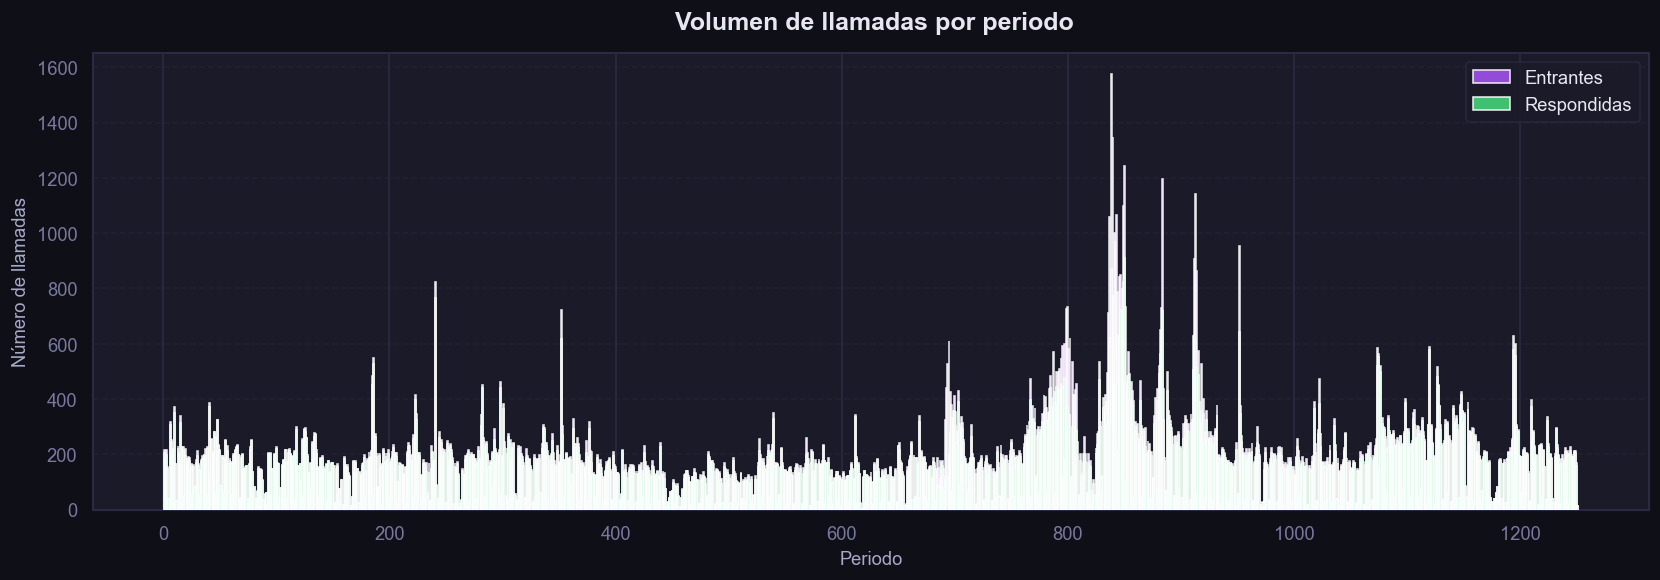

 Gráfica guardada: outputs/01_volumen_por_hora.png


In [19]:
# ── GRÁFICA 1: Volumen de interacciones por periodo ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f0f17')
ax.set_facecolor('#1a1a28')

x = df['Periodo'] if 'Periodo' in df.columns else df.index

bars_in  = ax.bar(x, df['Incoming Calls'],  color=PURPLE, alpha=0.85, label='Entrantes',   zorder=3)
bars_ans = ax.bar(x, df['Answered Calls'],  color=GREEN,  alpha=0.85, label='Respondidas', zorder=4)

ax.set_title(' Volumen de llamadas por periodo', fontsize=15, color='#e8e6f0',
             fontweight='bold', pad=14)
ax.set_xlabel('Periodo', fontsize=11)
ax.set_ylabel('Número de llamadas', fontsize=11)
ax.legend(facecolor='#1a1a28', edgecolor='#2a2a42', labelcolor='#e8e6f0')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../outputs/01_volumen_por_hora.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f17')
plt.show()
print(' Gráfica guardada: outputs/01_volumen_por_hora.png')

---
## 5. VISUALIZACIÓN 2 — Tasa de respuesta y abandono

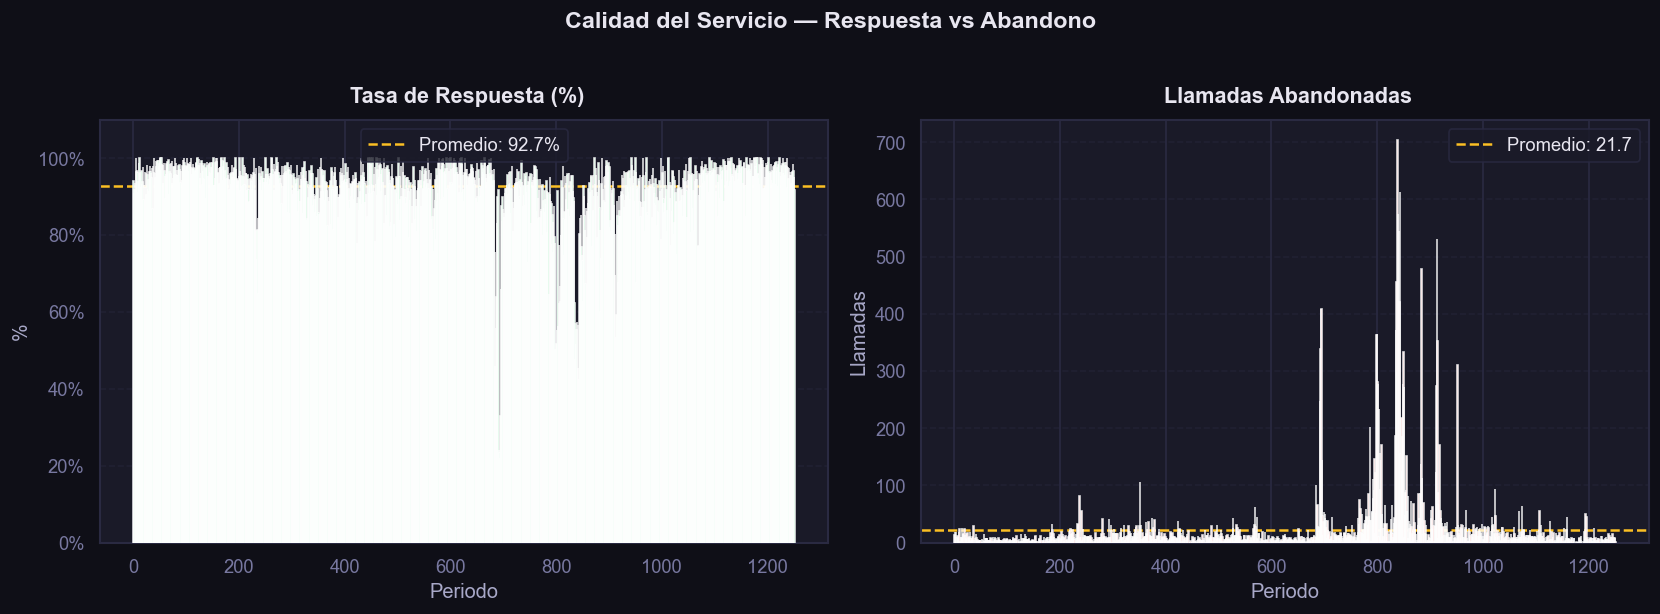

 Gráfica guardada: outputs/02_tipos_de_caso.png


In [20]:
# ── GRÁFICA 2: Tasa de respuesta vs tasa de abandono ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f17')

x = df['Periodo'] if 'Periodo' in df.columns else df.index

# Panel izquierdo — Answer Rate
ax1 = axes[0]
ax1.set_facecolor('#1a1a28')
ax1.bar(x, df['Answer Rate'], color=GREEN, alpha=0.85, zorder=3)
ax1.axhline(df['Answer Rate'].mean(), color=YELLOW, linestyle='--',
            linewidth=1.5, label=f'Promedio: {df["Answer Rate"].mean():.1f}%')
ax1.set_title(' Tasa de Respuesta (%)', fontsize=13, color='#e8e6f0',
              fontweight='bold', pad=10)
ax1.set_xlabel('Periodo'); ax1.set_ylabel('%')
ax1.set_ylim(0, 110)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(facecolor='#1a1a28', edgecolor='#2a2a42', labelcolor='#e8e6f0')
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)

# Panel derecho — Llamadas abandonadas
ax2 = axes[1]
ax2.set_facecolor('#1a1a28')
ax2.bar(x, df['Abandoned Calls'], color=RED, alpha=0.85, zorder=3)
ax2.axhline(df['Abandoned Calls'].mean(), color=YELLOW, linestyle='--',
            linewidth=1.5, label=f'Promedio: {df["Abandoned Calls"].mean():.1f}')
ax2.set_title(' Llamadas Abandonadas', fontsize=13, color='#e8e6f0',
              fontweight='bold', pad=10)
ax2.set_xlabel('Periodo'); ax2.set_ylabel('Llamadas')
ax2.legend(facecolor='#1a1a28', edgecolor='#2a2a42', labelcolor='#e8e6f0')
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle('Calidad del Servicio — Respuesta vs Abandono',
             fontsize=14, color='#e8e6f0', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_tipos_de_caso.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f17')
plt.show()
print(' Gráfica guardada: outputs/02_tipos_de_caso.png')

---
## 6. VISUALIZACIÓN 3 — Tiempos operativos

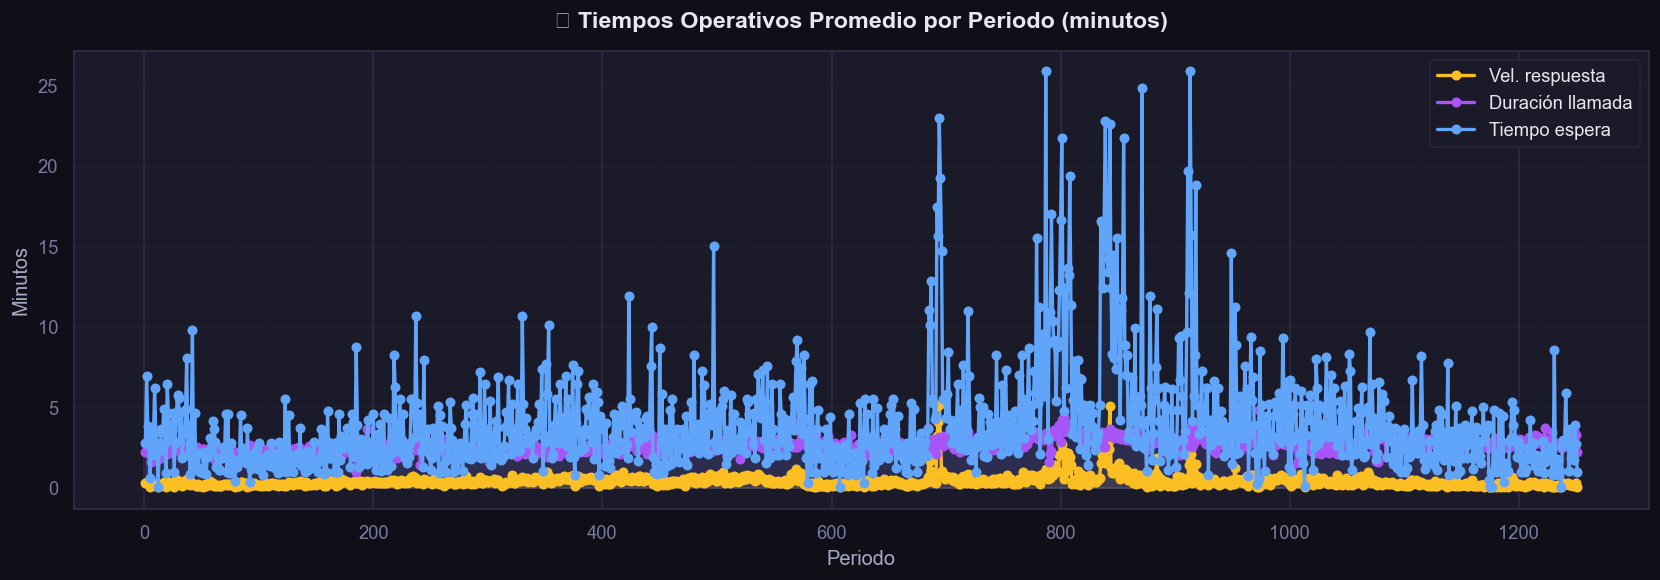

 Gráfica guardada: outputs/03_tiempo_resolucion.png


In [21]:
# ── GRÁFICA 3: Tiempos operativos por periodo ────────────────────────────────
time_sec_cols = [c for c in ['Answer Speed (AVG)_sec',
                              'Talk Duration (AVG)_sec',
                              'Waiting Time (AVG)_sec'] if c in df.columns]

if time_sec_cols:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f17')
    ax.set_facecolor('#1a1a28')

    colors_map = {
        'Answer Speed (AVG)_sec':   (YELLOW, 'Vel. respuesta'),
        'Talk Duration (AVG)_sec':  (PURPLE, 'Duración llamada'),
        'Waiting Time (AVG)_sec':   (BLUE,   'Tiempo espera'),
    }
    x = df['Periodo'] if 'Periodo' in df.columns else df.index

    for col in time_sec_cols:
        color, label = colors_map[col]
        ax.plot(x, df[col] / 60, marker='o', markersize=5,
                color=color, linewidth=2, label=label, zorder=3)
        ax.fill_between(x, df[col] / 60, alpha=0.10, color=color)

    ax.set_title('⏱ Tiempos Operativos Promedio por Periodo (minutos)',
                 fontsize=14, color='#e8e6f0', fontweight='bold', pad=14)
    ax.set_xlabel('Periodo'); ax.set_ylabel('Minutos')
    ax.legend(facecolor='#1a1a28', edgecolor='#2a2a42', labelcolor='#e8e6f0')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('../outputs/03_tiempo_resolucion.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f17')
    plt.show()
    print(' Gráfica guardada: outputs/03_tiempo_resolucion.png')
else:
    print('  No se encontraron columnas de tiempo convertidas.')

---
## 7. VISUALIZACIÓN 4 — Nivel de servicio (SLA)

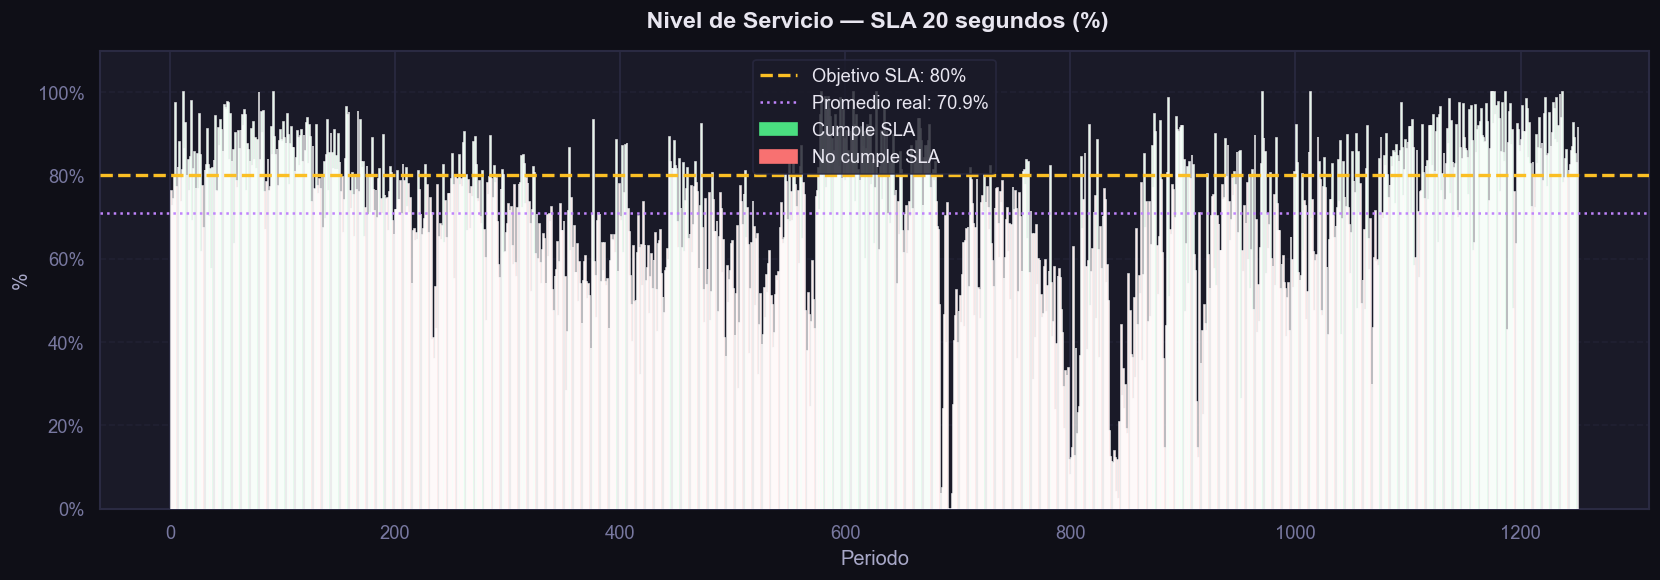

 Gráfica guardada: outputs/04_csat.png

   Periodos que cumplen SLA (≥80%): 458 / 1251


In [22]:
# ── GRÁFICA 4: Nivel de servicio (Service Level 20s) ────────────────────────
if 'Service Level (20 Seconds)' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f17')
    ax.set_facecolor('#1a1a28')

    x = df['Periodo'] if 'Periodo' in df.columns else df.index
    sla = df['Service Level (20 Seconds)']

    # Colorear barras según si cumplen el SLA objetivo (≥80%)
    SLA_TARGET = 80
    bar_colors = [GREEN if v >= SLA_TARGET else RED for v in sla]
    ax.bar(x, sla, color=bar_colors, alpha=0.85, zorder=3)

    # Línea objetivo
    ax.axhline(SLA_TARGET, color=YELLOW, linestyle='--', linewidth=2,
               label=f'Objetivo SLA: {SLA_TARGET}%', zorder=5)
    ax.axhline(sla.mean(), color=ACCENT, linestyle=':', linewidth=1.5,
               label=f'Promedio real: {sla.mean():.1f}%', zorder=5)

    green_patch = mpatches.Patch(color=GREEN, label='Cumple SLA')
    red_patch   = mpatches.Patch(color=RED,   label='No cumple SLA')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [green_patch, red_patch],
              facecolor='#1a1a28', edgecolor='#2a2a42', labelcolor='#e8e6f0')

    ax.set_title(' Nivel de Servicio — SLA 20 segundos (%)',
                 fontsize=14, color='#e8e6f0', fontweight='bold', pad=14)
    ax.set_xlabel('Periodo'); ax.set_ylabel('%')
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('../outputs/04_csat.png', dpi=150, bbox_inches='tight',
                facecolor='#0f0f17')
    plt.show()
    print(' Gráfica guardada: outputs/04_csat.png')
    print(f'\n   Periodos que cumplen SLA (≥{SLA_TARGET}%): '
          f'{(sla >= SLA_TARGET).sum()} / {len(sla)}')

---
## 8. VISUALIZACIÓN 5 — Dashboard resumen de KPIs

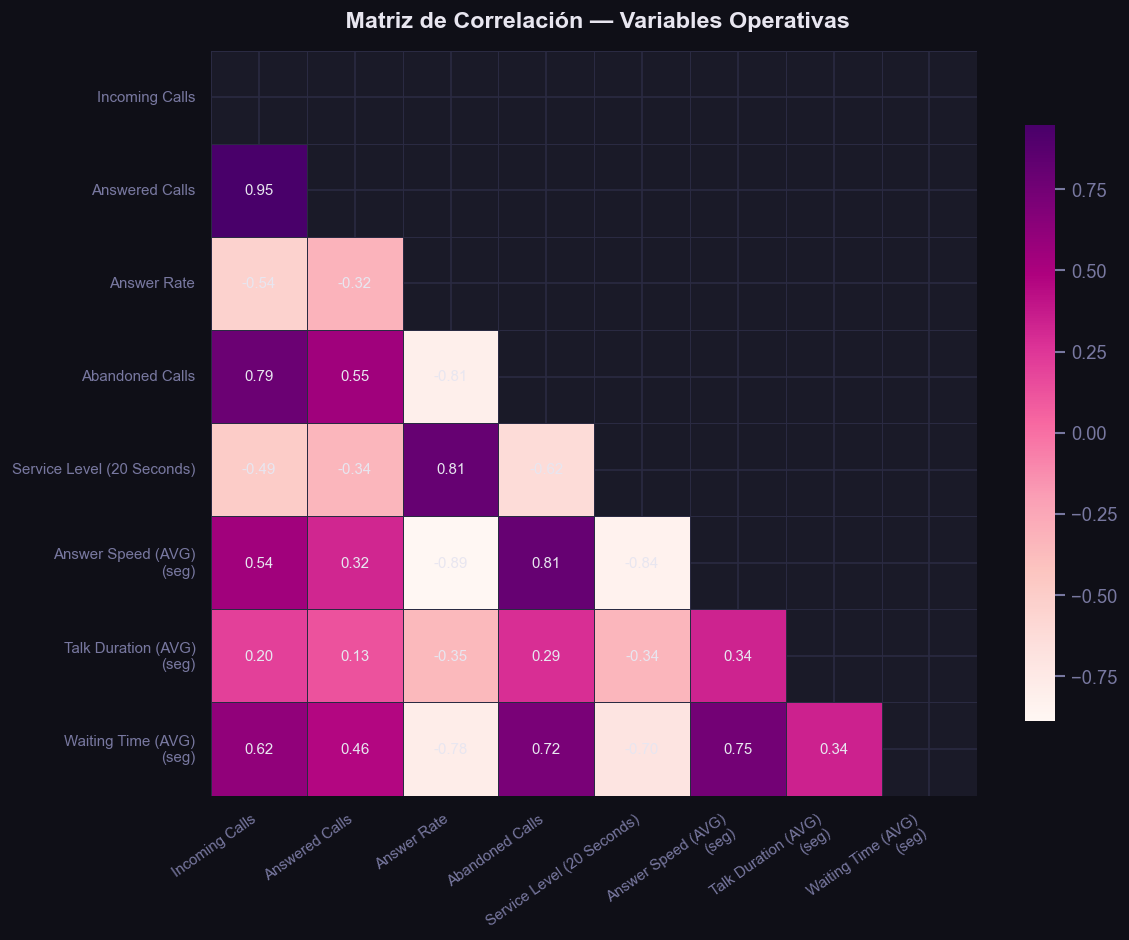

 Gráfica guardada: outputs/05_volumen_por_dia.png


In [23]:
# ── GRÁFICA 5: Correlación entre variables operativas ───────────────────────
numeric_cols = df.select_dtypes(include='number').columns.tolist()
# Excluir columna Periodo del heatmap
heatmap_cols = [c for c in numeric_cols if c not in ['Periodo']]

if len(heatmap_cols) >= 2:
    corr = df[heatmap_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#0f0f17')
    ax.set_facecolor('#1a1a28')

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f',
        cmap='RdPu', ax=ax,
        linewidths=0.5, linecolor='#2a2a42',
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 9, 'color': '#e8e6f0'}
    )

    # Etiquetas más legibles
    labels = [l.get_text().replace('_sec','\n(seg)') for l in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(labels, rotation=0, fontsize=9)

    ax.set_title(' Matriz de Correlación — Variables Operativas',
                 fontsize=14, color='#e8e6f0', fontweight='bold', pad=14)

    plt.tight_layout()
    plt.savefig('../outputs/05_volumen_por_dia.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f17')
    plt.show()
    print(' Gráfica guardada: outputs/05_volumen_por_dia.png')

---
## 9. ANÁLISIS ESTADÍSTICO AVANZADO

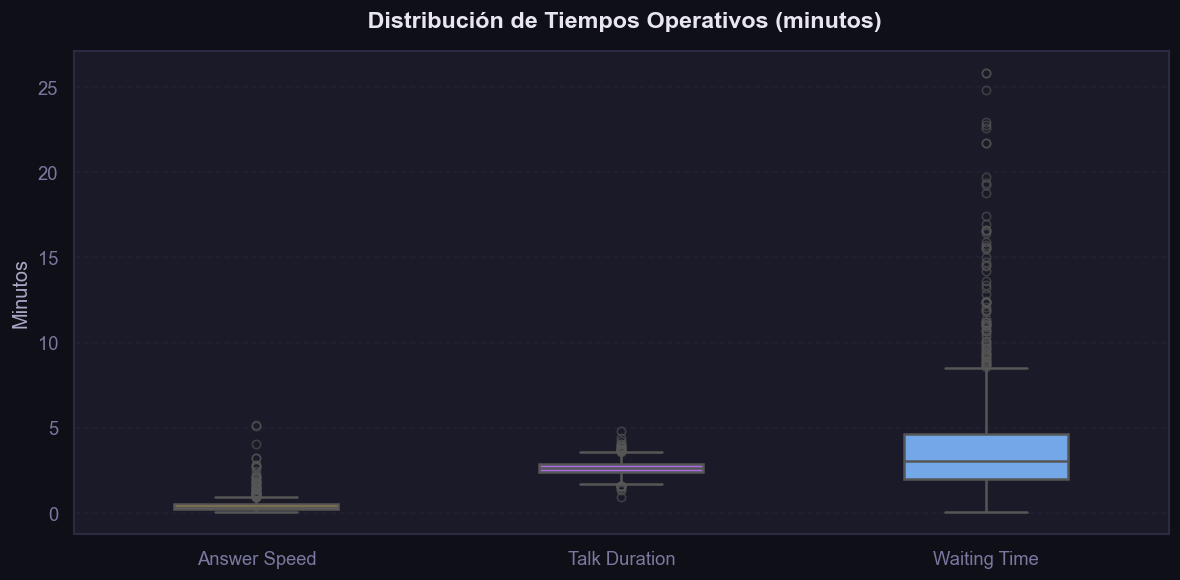

In [24]:
# ── ANÁLISIS: Distribución de tiempos con boxplot ───────────────────────────
time_sec_cols = [c for c in ['Answer Speed (AVG)_sec',
                              'Talk Duration (AVG)_sec',
                              'Waiting Time (AVG)_sec'] if c in df.columns]

if time_sec_cols:
    df_times = df[time_sec_cols].copy() / 60  # convertir a minutos
    df_times.columns = [c.replace('_sec','').replace(' (AVG)','') for c in time_sec_cols]
    df_melt = df_times.melt(var_name='Métrica', value_name='Minutos')

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#0f0f17')
    ax.set_facecolor('#1a1a28')

    sns.boxplot(
        data=df_melt, x='Métrica', y='Minutos', ax=ax,
        palette=[YELLOW, PURPLE, BLUE],
        width=0.45, linewidth=1.5,
        flierprops=dict(marker='o', color=ACCENT, alpha=0.6, markersize=5)
    )
    ax.set_title(' Distribución de Tiempos Operativos (minutos)',
                 fontsize=14, color='#e8e6f0', fontweight='bold', pad=14)
    ax.set_xlabel(''); ax.set_ylabel('Minutos')
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

In [25]:
# ── ANÁLISIS: Periodos críticos (llamadas no respondidas) ────────────────────
if 'Abandoned Calls' in df.columns and 'Incoming Calls' in df.columns:
    df['Abandonment_Rate'] = (df['Abandoned Calls'] / df['Incoming Calls'] * 100).round(2)
    criticos = df[df['Abandonment_Rate'] > df['Abandonment_Rate'].mean()].copy()

    print(' Periodos con tasa de abandono SUPERIOR al promedio:')
    print(f'   Promedio general: {df["Abandonment_Rate"].mean():.2f}%')
    print()
    cols_show = ['Periodo', 'Incoming Calls', 'Abandoned Calls', 'Abandonment_Rate']
    cols_show = [c for c in cols_show if c in criticos.columns]
    print(criticos[cols_show].to_string(index=False))

 Periodos con tasa de abandono SUPERIOR al promedio:
   Promedio general: 7.31%

 Periodo  Incoming Calls  Abandoned Calls  Abandonment_Rate
       2             200               18              9.00
       3             216               18              8.33
       9             219               19              8.68
      15             338               25              7.40
      20             218               24             11.01
      23             188               14              7.45
      25             166               16              9.64
      28              86                7              8.14
      30             210               18              8.57
      37             218               29             13.30
      61              57                6             10.53
      68              43                4              9.30
     138              48                5             10.42
     182             207               17              8.21
     203           

---
## 10. CONCLUSIONES Y HALLAZGOS

In [26]:
# ── RESUMEN EJECUTIVO ────────────────────────────────────────────────────────
print('═'*60)
print('            RESUMEN EJECUTIVO — CALL CENTER')
print('═'*60)

# 1. Volumen
print(f'\n VOLUMEN')
print(f'   Total llamadas entrantes : {df["Incoming Calls"].sum():,.0f}')
print(f'   Total llamadas respondidas: {df["Answered Calls"].sum():,.0f}')
print(f'   Total abandonadas         : {df["Abandoned Calls"].sum():,.0f}')

# 2. Eficiencia
print(f'\n EFICIENCIA')
print(f'   Tasa de respuesta promedio : {df["Answer Rate"].mean():.2f}%')
if 'Abandonment_Rate' in df.columns:
    print(f'   Tasa de abandono promedio  : {df["Abandonment_Rate"].mean():.2f}%')

# 3. Tiempos
print(f'\n  TIEMPOS PROMEDIO')
for col, label in [('Answer Speed (AVG)_sec', 'Velocidad de respuesta'),
                    ('Talk Duration (AVG)_sec', 'Duración de llamada  '),
                    ('Waiting Time (AVG)_sec',  'Tiempo de espera     ')]:
    if col in df.columns:
        val = df[col].mean()
        mins, secs = divmod(int(val), 60)
        print(f'   {label}: {mins}m {secs:02d}s')

# 4. SLA
if 'Service Level (20 Seconds)' in df.columns:
    sla = df['Service Level (20 Seconds)']
    print(f'\n NIVEL DE SERVICIO (SLA)')
    print(f'   SLA promedio              : {sla.mean():.2f}%')
    print(f'   SLA máximo                : {sla.max():.2f}%')
    print(f'   SLA mínimo                : {sla.min():.2f}%')
    print(f'   Periodos que cumplen ≥80% : {(sla >= 80).sum()} / {len(sla)}')

print('\n' + '═'*60)
print(' Análisis completado exitosamente')
print('   Todas las gráficas exportadas en: ../outputs/')
print('═'*60)

════════════════════════════════════════════════════════════
            RESUMEN EJECUTIVO — CALL CENTER
════════════════════════════════════════════════════════════

 VOLUMEN
   Total llamadas entrantes : 248,373
   Total llamadas respondidas: 221,234
   Total abandonadas         : 27,139

 EFICIENCIA
   Tasa de respuesta promedio : 92.69%
   Tasa de abandono promedio  : 7.31%

  TIEMPOS PROMEDIO
   Velocidad de respuesta: 0m 24s
   Duración de llamada  : 2m 37s
   Tiempo de espera     : 3m 52s

 NIVEL DE SERVICIO (SLA)
   SLA promedio              : 70.87%
   SLA máximo                : 100.00%
   SLA mínimo                : 0.00%
   Periodos que cumplen ≥80% : 458 / 1251

════════════════════════════════════════════════════════════
 Análisis completado exitosamente
   Todas las gráficas exportadas en: ../outputs/
════════════════════════════════════════════════════════════
